In [1]:
import pandas as pd  
import datetime as dt  
import numpy as np  
import datetime as dt  
import matplotlib.pyplot as plt  
import seaborn as sns  
from  scipy.stats import skew, kurtosis, shapiro

In [2]:
path= "spain_energy_market.csv"
data = pd.read_csv(path, sep=",", parse_dates=["datetime"])  
data = data[data["name"]=="Demanda programada PBF total"]#.set_index("datetime")  
data["date"] = data["datetime"].dt.date  
data.set_index("date", inplace=True)  
data = data[["value"]]  
data = data.asfreq("D")  
data = data.rename(columns={"value": "energy"})  
data.info()       

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1825 entries, 2014-01-01 to 2018-12-30
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   energy  1825 non-null   float64
dtypes: float64(1)
memory usage: 28.5 KB


In [3]:
data[:5]  

,energy
date,
2014-01-01,620107.7
2014-01-02,659865.2
2014-01-03,632536.8
2014-01-04,610251.7
2014-01-05,572534.1


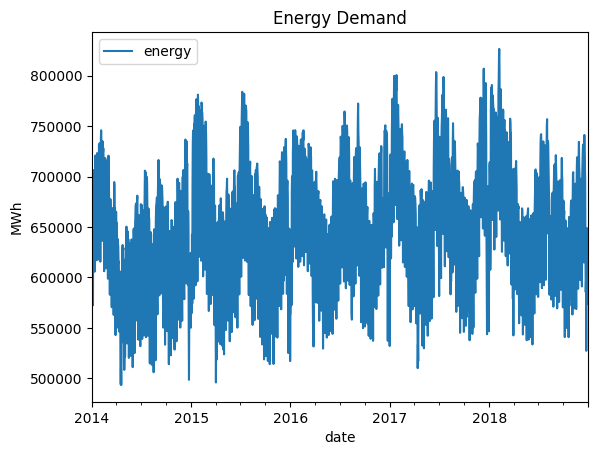

In [4]:
data.plot(title="Energy Demand")  
plt.ylabel("MWh")  
plt.show()  

In [5]:
len(pd.date_range(start="2014-01-01", end="2018-12-31")) 

1826

C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\3043401185.py:6: FutureWarning: The provided callable <function mean at 0x00000191FF92B920> is currently using Rolling.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data[["movave_7", "movstd_7"]] = data.energy.rolling(7).agg([np.mean, np.std])
C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\3043401185.py:6: FutureWarning: The provided callable <function std at 0x00000191FF92BA60> is currently using Rolling.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  data[["movave_7", "movstd_7"]] = data.energy.rolling(7).agg([np.mean, np.std])
C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\3043401185.py:7: FutureWarning: The provided callable <function mean at 0x00000191FF92B920> is currently using Rolling.mean. In a future version of pandas, the provided callable 

<Figure size 2000x1600 with 0 Axes>

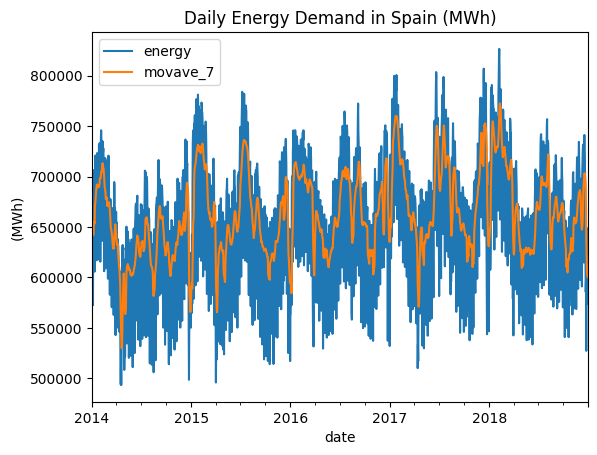

In [8]:
data["year"] = data.index.year  
data["qtr"] = data.index.quarter  
data["mon"] = data.index.month  
data["week"] = data.index.isocalendar().week
data["ix"] = range(0,len(data))  
data[["movave_7", "movstd_7"]] = data.energy.rolling(7).agg([np.mean, np.std])  
data[["movave_30", "movstd_30"]] = data.energy.rolling(30).agg([np.mean, np.std])  
data[["movave_90", "movstd_90"]] = data.energy.rolling(90).agg([np.mean, np.std])  
data[["movave_365", "movstd_365"]] = data.energy.rolling(365).agg([np.mean, np.std])  
  
plt.figure(figsize=(20,16))  
data[["energy", "movave_7"]].plot(title="Daily Energy Demand in Spain (MWh)")  
plt.ylabel("(MWh)")  
plt.show()  

In [9]:
mean = np.mean(data.energy.values)  
std = np.std(data.energy.values)  
skew = skew(data.energy.values)  
ex_kurt = kurtosis(data.energy)  
print("Skewness: {} \nKurtosis: {}".format(skew, ex_kurt+3))  

Skewness: -0.2555279252628293 
Kurtosis: 2.6052606972453667


In [10]:
def shapiro_test(data, alpha=0.05):  
    stat, pval = shapiro(data)  
    print("H0: Data was drawn from a Normal Ditribution")  
    if (pval<alpha):  
        print("pval {} is lower than significance level: {}, therefore null hypothesis is rejected".format(pval, alpha))  
    else:  
        print("pval {} is higher than significance level: {}, therefore null hypothesis cannot be rejected".format(pval, alpha))  
          
shapiro_test(data.energy, alpha=0.05)  

H0: Data was drawn from a Normal Ditribution
pval 2.5468191851953216e-10 is lower than significance level: 0.05, therefore null hypothesis is rejected


C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\1462587403.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data.energy)


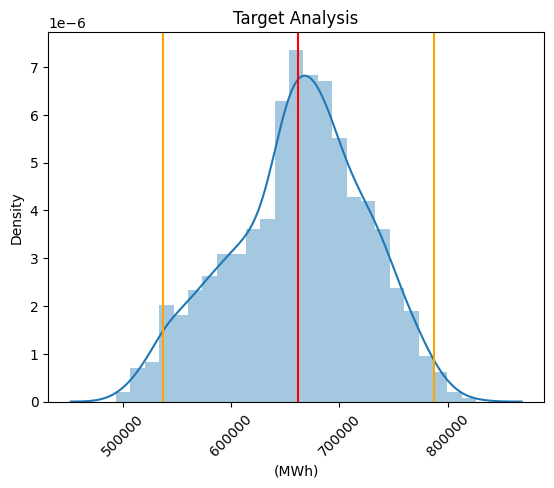

In [11]:
sns.distplot(data.energy)  
plt.title("Target Analysis")  
plt.xticks(rotation=45)  
plt.xlabel("(MWh)")  
plt.axvline(x=mean, color='r', linestyle='-', label="\mu: {0:.2f}%".format(mean))  
plt.axvline(x=mean+2*std, color='orange', linestyle='-')  
plt.axvline(x=mean-2*std, color='orange', linestyle='-')  
plt.show()  

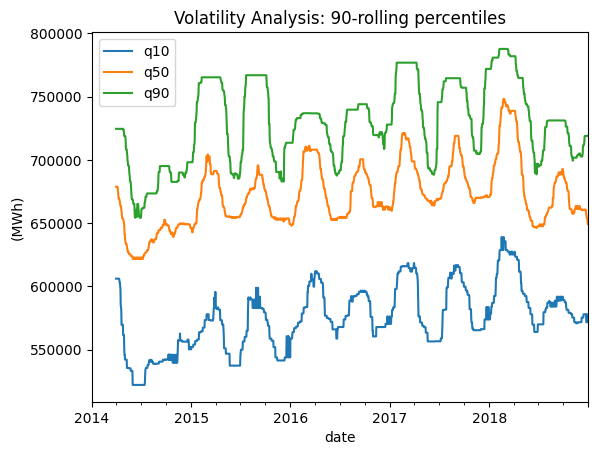

In [12]:
data_rolling = data.energy.rolling(window=90)  
data['q10'] = data_rolling.quantile(0.1).to_frame("q10")  
data['q50'] = data_rolling.quantile(0.5).to_frame("q50")  
data['q90'] = data_rolling.quantile(0.9).to_frame("q90")  
  
data[["q10", "q50", "q90"]].plot(title="Volatility Analysis: 90-rolling percentiles")  
plt.ylabel("(MWh)")  
plt.show()  

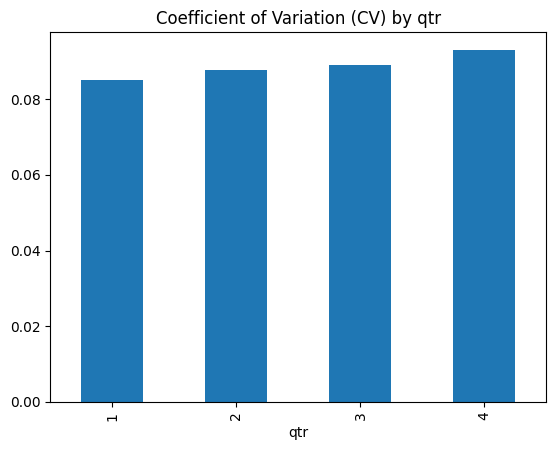

In [13]:
data.groupby("qtr")["energy"].std().divide(data.groupby("qtr")["energy"].mean()).plot(kind="bar")  
plt.title("Coefficient of Variation (CV) by qtr")  
plt.show()  

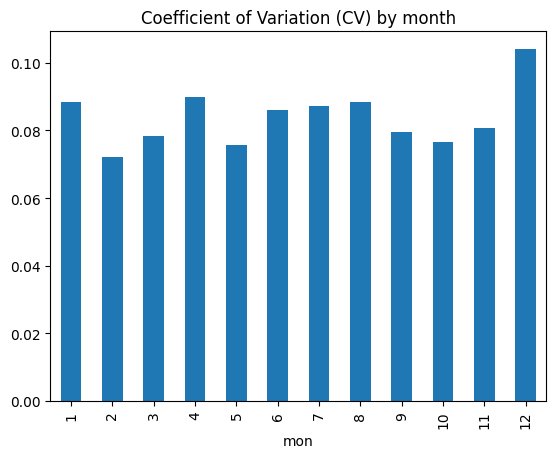

In [14]:
data.groupby("mon")["energy"].std().divide(data.groupby("mon")["energy"].mean()).plot(kind="bar")  
plt.title("Coefficient of Variation (CV) by month")  
plt.show()  

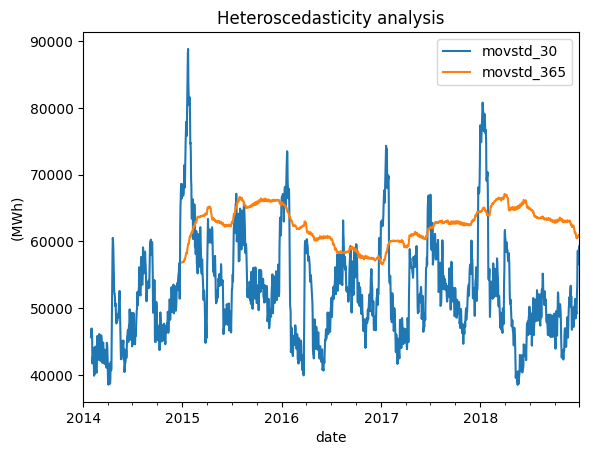

In [15]:
data[["movstd_30", "movstd_365"]].plot(title="Heteroscedasticity analysis")  
plt.ylabel("(MWh)")  
plt.show() 

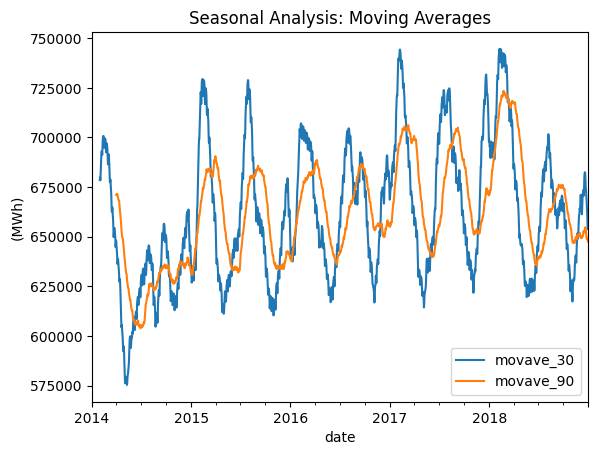

In [16]:
data[["movave_30", "movave_90"]].plot(title="Seasonal Analysis: Moving Averages")  
plt.ylabel("(MWh)")  
plt.show() 

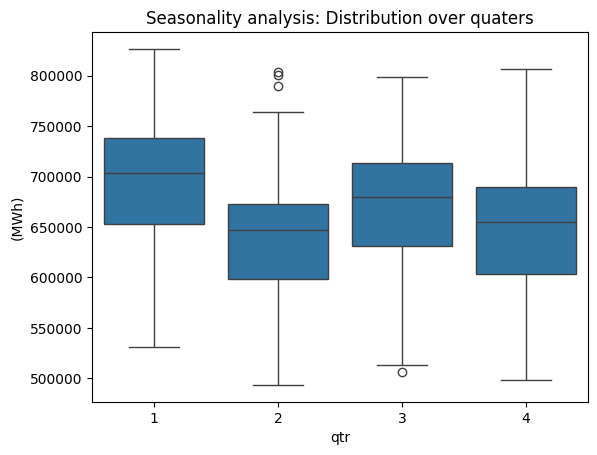

In [17]:
sns.boxplot(data=data, x="qtr", y="energy")  
plt.title("Seasonality analysis: Distribution over quaters")  
plt.ylabel("(MWh)")  
plt.show()  

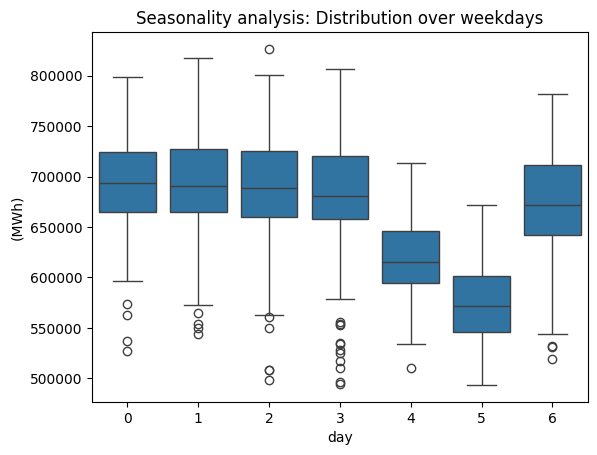

In [20]:
data["day"] = data.index.weekday
sns.boxplot(data=data, x="day", y="energy")
plt.title("Seasonality analysis: Distribution over weekdays")
plt.ylabel("(MWh)")
plt.show()



In [21]:
data_mon = data. energy.resample("M").agg(sum).to_frame("energy")  
data_mon["ix"] = range(0, len(data_mon))  
data_mon[:5] 

C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\2298493585.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_mon = data. energy.resample("M").agg(sum).to_frame("energy")
C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\2298493585.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DatetimeIndexResampler.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  data_mon = data. energy.resample("M").agg(sum).to_frame("energy")


,energy,ix
date,,
2014-01-31,21017412.7,0
2014-02-28,19336398.7,1
2014-03-31,20040978.6,2
2014-04-30,17633177.7,3
2014-05-31,18572681.6,4


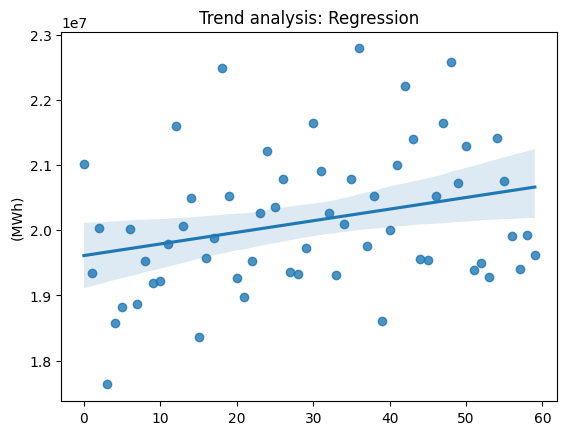

In [22]:
sns.regplot(data=data_mon,x="ix", y="energy")  
plt.title("Trend analysis: Regression")  
plt.ylabel("(MWh)")  
plt.xlabel("")  
plt.show()  

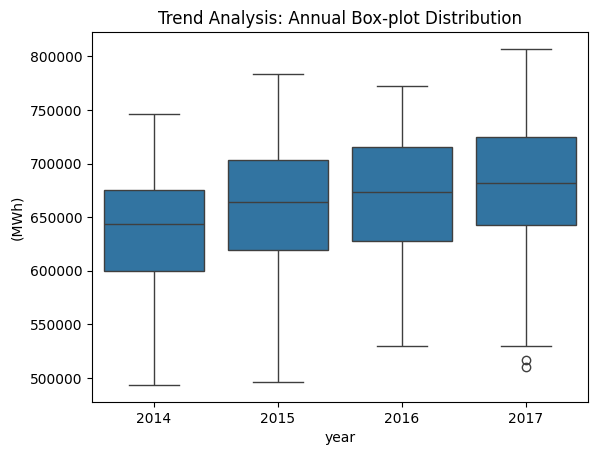

In [24]:
sns.boxplot(data=data["2014":"2017"], x="year", y="energy")  
plt.title("Trend Analysis: Annual Box-plot Distribution")  
plt.ylabel("(MWh)")  
plt.show()  


C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\3382795097.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["target"])


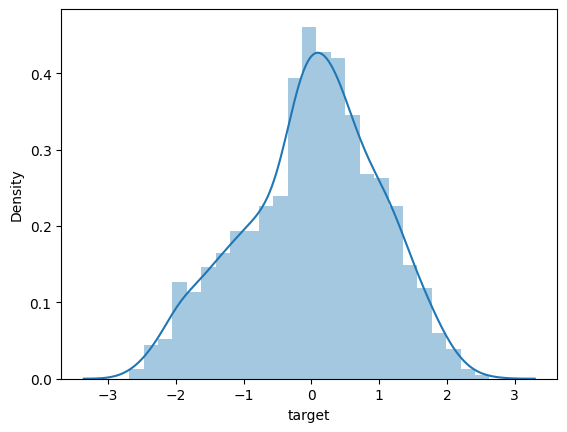

In [25]:
data["target"] = data.energy.add(-mean).div(std)  
sns.distplot(data["target"])  
plt.show() 

C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\3381360120.py:19: FutureWarning: The provided callable <function mean at 0x00000191FF92B920> is currently using Rolling.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data[["feat_movave" + str(t), "feat_movstd" + str(t), "feat_movmin" + str(t) ,"feat_movmax" + str(t)]] = data.energy.rolling(t).agg([np.mean, np.std, np.max, np.min])
C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\3381360120.py:19: FutureWarning: The provided callable <function std at 0x00000191FF92BA60> is currently using Rolling.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  data[["feat_movave" + str(t), "feat_movstd" + str(t), "feat_movmin" + str(t) ,"feat_movmax" + str(t)]] = data.energy.rolling(t).agg([np.mean, np.std, np.max, np.min])
C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\

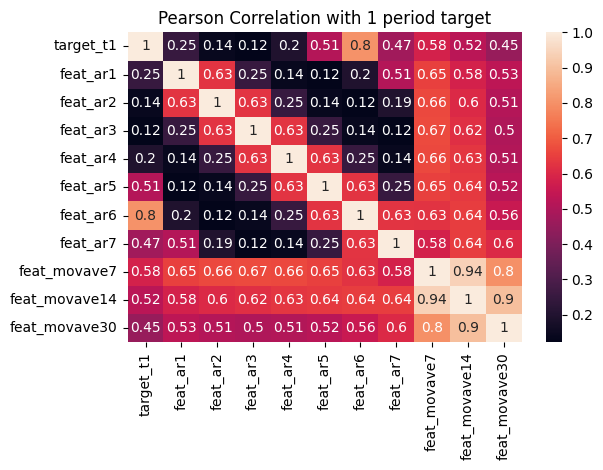

In [26]:
features = []  
corr_features=[]  
targets = []  
tau = 30 #forecasting periods  
  
for t in range(1, tau+1):  
    data["target_t" + str(t)] = data.target.shift(-t)  
    targets.append("target_t" + str(t))  
      
for t in range(1,31):  
    data["feat_ar" + str(t)] = data.target.shift(t)  
    #data["feat_ar" + str(t) + "_lag1y"] = data.target.shift(350)  
    features.append("feat_ar" + str(t))  
    #corr_features.append("feat_ar" + str(t))  
    #features.append("feat_ar" + str(t) + "_lag1y")  
          
      
for t in [7, 14, 30]:  
    data[["feat_movave" + str(t), "feat_movstd" + str(t), "feat_movmin" + str(t) ,"feat_movmax" + str(t)]] = data.energy.rolling(t).agg([np.mean, np.std, np.max, np.min])  
    features.append("feat_movave" + str(t))  
    #corr_features.append("feat_movave" + str(t))  
    features.append("feat_movstd" + str(t))  
    features.append("feat_movmin" + str(t))  
    features.append("feat_movmax" + str(t))  
      
months = pd.get_dummies(data.mon,  
                              prefix="mon",  
                              drop_first=True)  
months.index = data.index  
data = pd.concat([data, months], axis=1)  
  
days = pd.get_dummies(data.day,  
                              prefix="day",  
                              drop_first=True)  
days.index = data.index  
data = pd.concat([data, days], axis=1)  
  
  
features = features + months.columns.values.tolist() + days.columns.values.tolist()  

corr_features = ["feat_ar1", "feat_ar2", "feat_ar3", "feat_ar4", "feat_ar5", "feat_ar6", "feat_ar7", "feat_movave7", "feat_movave14", "feat_movave30"]  

# Calculate correlation matrix  
corr = data[["target_t1"] + corr_features].corr()  
  
top5_mostCorrFeats = corr["target_t1"].apply(abs).sort_values(ascending=False).index.values[:6]  
  
  
# Plot heatmap of correlation matrix  
sns.heatmap(corr, annot=True)  
plt.title("Pearson Correlation with 1 period target")  
plt.yticks(rotation=0); plt.xticks(rotation=90)  # fix ticklabel directions  
plt.tight_layout()  # fits plot area to the plot, "tightly"  
plt.show()  # show the plot  

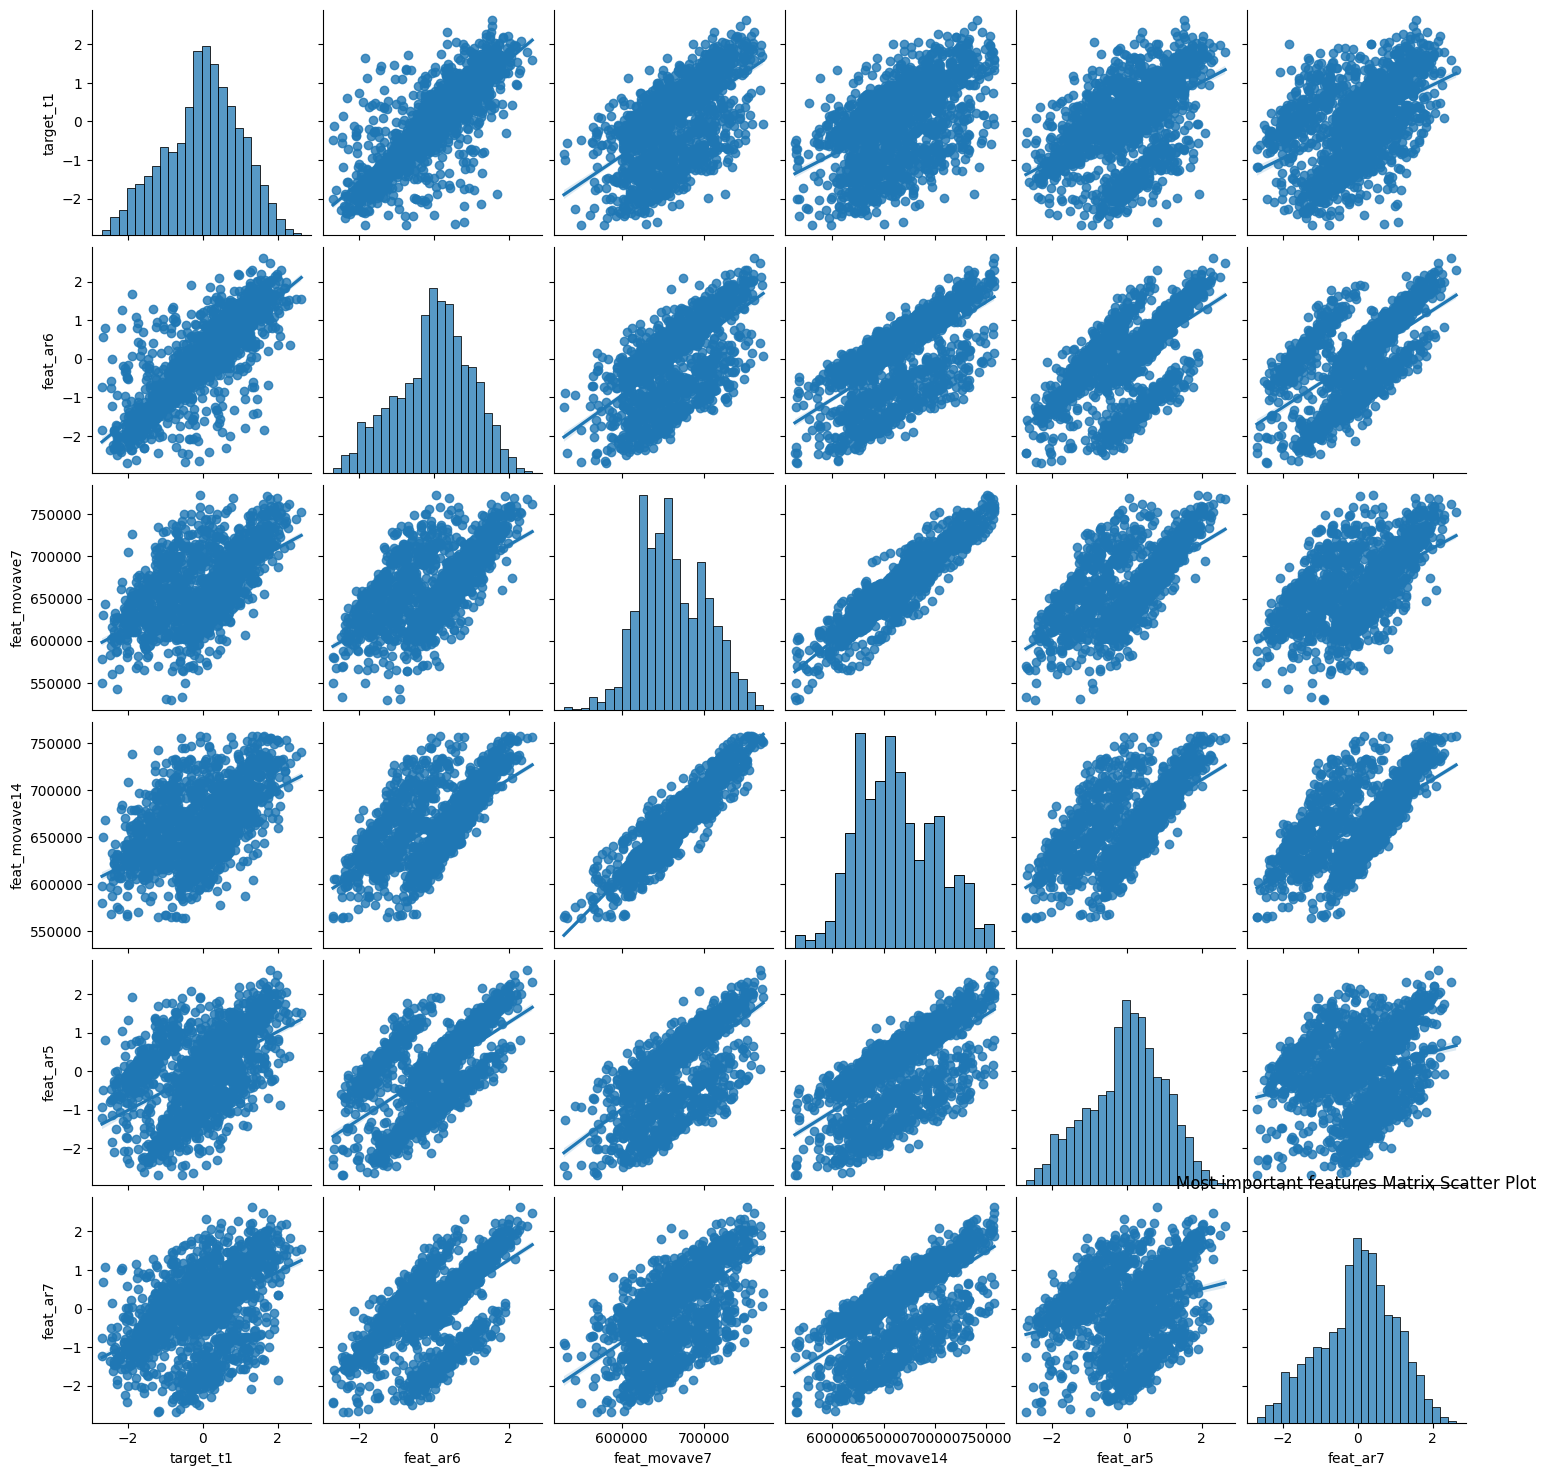

In [27]:
sns.pairplot(data=data[top5_mostCorrFeats].dropna(), kind="reg")  
plt.title("Most important features Matrix Scatter Plot")  
plt.show()  

In [28]:
data_feateng = data[features + targets].dropna()  
nobs= len(data_feateng)  
print("Number of observations: ", nobs) 

Number of observations:  1765


Total number of observations:  1765
Train: (1431, 59)(1431, 30), 
Test: (334, 59)(334, 30)


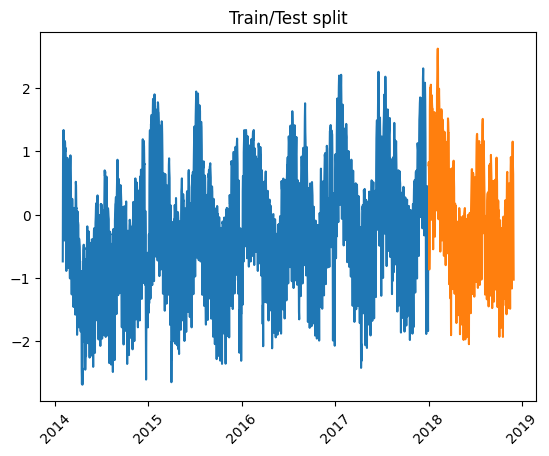

In [29]:
X_train = data_feateng.loc["2014":"2017"][features]  
y_train = data_feateng.loc["2014":"2017"][targets]  
  
X_test = data_feateng.loc["2018"][features]  
y_test = data_feateng.loc["2018"][targets]  
  
n, k = X_train.shape  
print("Total number of observations: ", nobs)  
print("Train: {}{}, \nTest: {}{}".format(X_train.shape, y_train.shape,  
                                              X_test.shape, y_test.shape))  
  
plt.plot(y_train.index, y_train.target_t1.values, label="train")  
plt.plot(y_test.index, y_test.target_t1.values, label="test")  
plt.title("Train/Test split")  
plt.xticks(rotation=45)  
plt.show()  

In [30]:
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_error  
  
reg = LinearRegression().fit(X_train, y_train["target_t1"])  
p_train = reg.predict(X_train)  
p_test = reg.predict(X_test)  
  
RMSE_train = np.sqrt(mean_squared_error(y_train["target_t1"], p_train))  
RMSE_test = np.sqrt(mean_squared_error(y_test["target_t1"], p_test))  
  
print("Train RMSE: {}\nTest RMSE: {}".format(RMSE_train, RMSE_test) )  

Train RMSE: 0.33298000709497844
Test RMSE: 0.27705159884085256


TRAIN: 360 TEST: 357


C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\1235977729.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train["target_t1"][train_index].plot()
C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\1235977729.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train["target_t1"][val_index].plot()


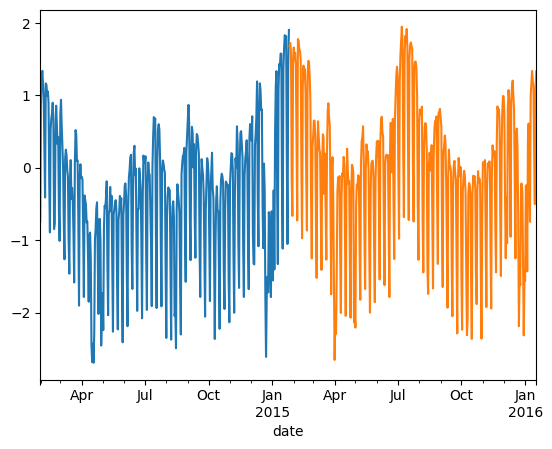

TRAIN: 717 TEST: 357


C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\1235977729.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train["target_t1"][train_index].plot()
C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\1235977729.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train["target_t1"][val_index].plot()


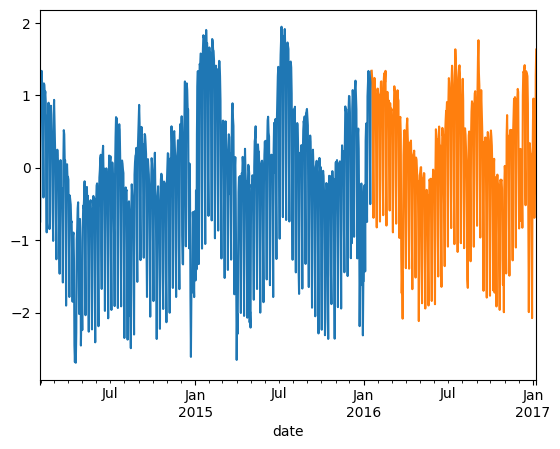

TRAIN: 730 TEST: 357


C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\1235977729.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train["target_t1"][train_index].plot()
C:\Users\goopb\AppData\Local\Temp\ipykernel_1700\1235977729.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train["target_t1"][val_index].plot()


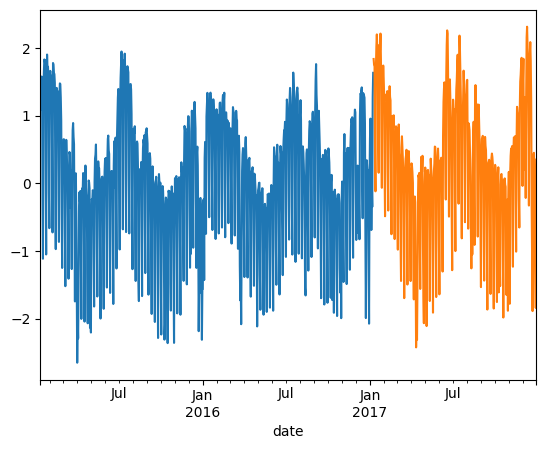

In [31]:
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid  
  
splits = TimeSeriesSplit(n_splits=3, max_train_size=365*2)  
for train_index, val_index in splits.split(X_train):  
    print("TRAIN:", len(train_index), "TEST:", len(val_index))  
    y_train["target_t1"][train_index].plot()  
    y_train["target_t1"][val_index].plot()  
    plt.show()  

In [32]:
from sklearn.ensemble import RandomForestRegressor  
  
splits = TimeSeriesSplit(n_splits=3, max_train_size=365*2)  
rfr = RandomForestRegressor()  
# Create a dictionary of hyperparameters to search  
rfr_grid = {"n_estimators": [500],   
        'max_depth': [3, 5, 10, 20, 30],   
        'max_features': [4, 8, 16, 32, 59],   
        'random_state': [123]}  
rfr_paramGrid = ParameterGrid(rfr_grid)  
  
def TimeSplit_ModBuild(model, paramGrid, splits, X, y):  
    from sklearn.model_selection import TimeSeriesSplit  
    from sklearn.metrics import mean_squared_error  
  
    #Loop over each time split and for each  
    for train_index, val_index in splits.split(X_train):  
        _X_train_ = X.iloc[train_index]  
        _y_train_ = y.iloc[train_index]  
        _X_val_ = X.iloc[val_index]  
        _y_val_ = y.iloc[val_index]  
  
        train_scores = []  
        val_scores = []  
        #models = []  
          
        # Loop through the parameter grid, set the hyperparameters, and save the scores  
        for g in paramGrid:  
            model.set_params(**g)  
            model.fit(_X_train_, _y_train_)  
            p_train = model.predict(_X_train_)  
            p_val = model.predict(_X_val_)  
            score_train = np.mean(mean_squared_error(_y_train_, p_train))  
            score_val = np.mean(mean_squared_error(_y_val_, p_val))  
            train_scores.append(score_train)  
            val_scores.append(score_val)  
            #models.append(model)  
            best_idx = np.argmin(val_scores)  
              
        print("Best-Fold HyperParams:: ", paramGrid[best_idx])  
        print("Best-Fold Train RMSE: ", train_scores[best_idx])  
        print("Best-Fold Val RMSE: ",val_scores[best_idx])  
        print("\n")  
          
    #Return the most recent model  
    return train_scores, val_scores, best_idx  
  
  
CV_rfr_tup = TimeSplit_ModBuild(rfr, rfr_paramGrid, splits, X_train, y_train["target_t1"])  

Best-Fold HyperParams::  {'random_state': 123, 'n_estimators': 500, 'max_features': 32, 'max_depth': 10}
Best-Fold Train RMSE:  0.030324468201182342
Best-Fold Val RMSE:  0.21215787764817834


Best-Fold HyperParams::  {'random_state': 123, 'n_estimators': 500, 'max_features': 16, 'max_depth': 20}
Best-Fold Train RMSE:  0.022225084451683037
Best-Fold Val RMSE:  0.18590042166791146


Best-Fold HyperParams::  {'random_state': 123, 'n_estimators': 500, 'max_features': 16, 'max_depth': 10}
Best-Fold Train RMSE:  0.028482009744979626
Best-Fold Val RMSE:  0.217026072216893




In [36]:
best_rfr_idx = CV_rfr_tup[2]
best_rfr_grid = rfr_paramGrid[best_rfr_idx]
best_rfr = RandomForestRegressor().set_params(**best_rfr_grid)
best_rfr.fit(X_train.loc["2016":"2017"], y_train.loc["2016":"2017", "target_t1"])


RandomForestRegressor(max_depth=10, max_features=16, n_estimators=500,
                      random_state=123)

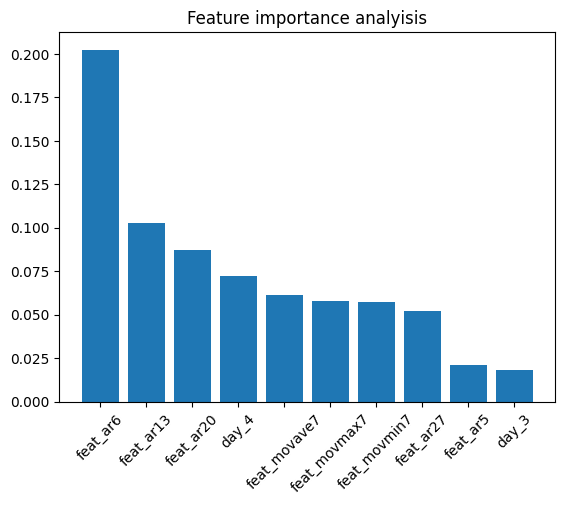

In [37]:
# Get feature importances from our random forest model  
importances = best_rfr.feature_importances_  
  
# Get the index of importance from greatest importance to least  
sorted_index = np.argsort(importances)[::-1]  
sorted_index_top = sorted_index[:10]  
x = range(len(sorted_index_top))  
  
# Create tick labels   
labels = np.array(features)[sorted_index_top]  
plt.bar(x, importances[sorted_index_top], tick_label=labels)  
plt.title("Feature importance analyisis")  
# Rotate tick labels to vertical  
plt.xticks(rotation=45)  
plt.show()  

In [38]:
p_train = best_rfr.predict(X_train)  
train_resid_1step = y_train["target_t1"]- p_train  
  
p_test = best_rfr.predict(X_test)  
test_resid_1step = y_test["target_t1"]- p_test  

In [39]:
test_df = y_test[["target_t1"]]*std+mean  
test_df["pred_t1"] = p_test*std+mean  
test_df["resid_t1"] = test_df["target_t1"].add(-test_df["pred_t1"])  
test_df["abs_resid_t1"] = abs(test_df["resid_t1"])  
test_df["ape_t1"] = test_df["resid_t1"].div(test_df["target_t1"])  
  
test_MAPE = test_df["ape_t1"].mean()*100  
print("1-period ahead forecasting MAPE: ", test_MAPE)  

1-period ahead forecasting MAPE:  0.08747070456988605


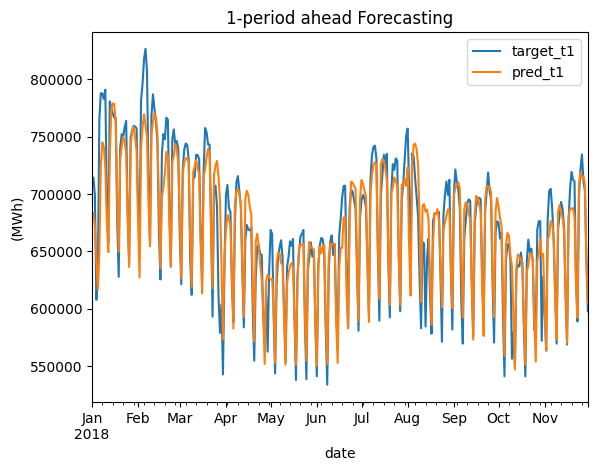

In [40]:
test_df[["target_t1", "pred_t1"]].plot()  
  
plt.title("1-period ahead Forecasting")  
plt.ylabel("(MWh)")  
plt.legend()  
plt.show()  

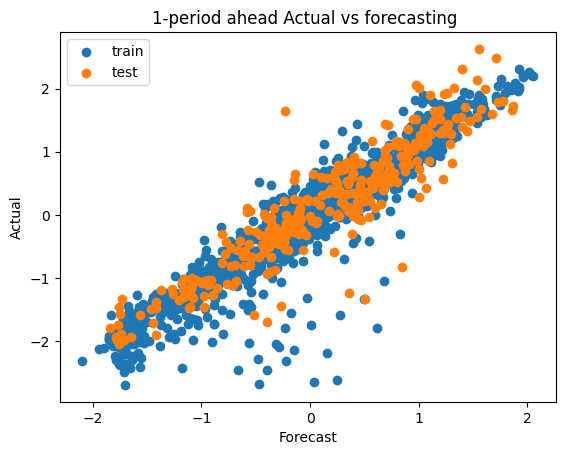

In [41]:
plt.scatter(y=y_train["target_t1"],x=p_train, label="train")  
plt.scatter(y=y_test["target_t1"],x=p_test, label="test")  
plt.title("1-period ahead Actual vs forecasting ")  
plt.ylabel("Actual")  
plt.xlabel("Forecast")  
plt.legend()  
plt.show()  

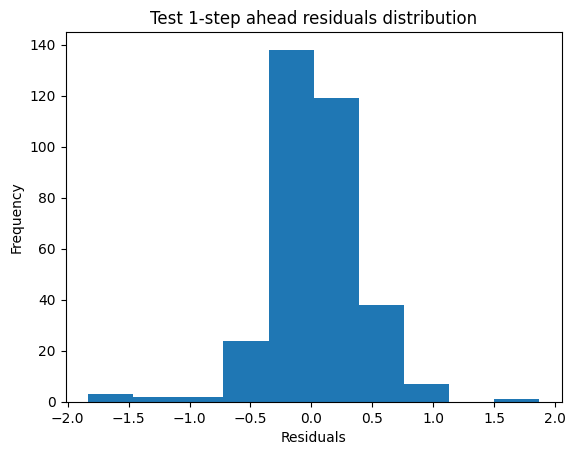

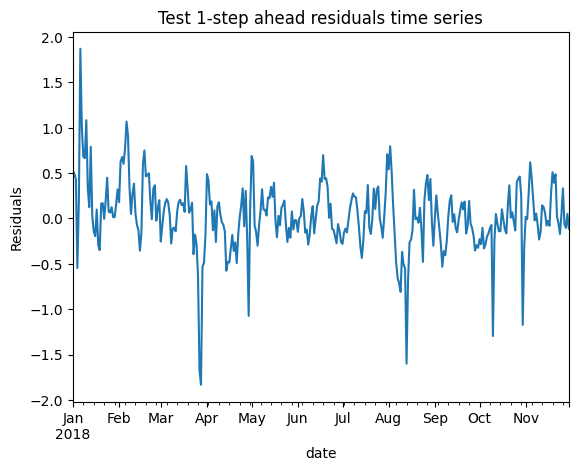

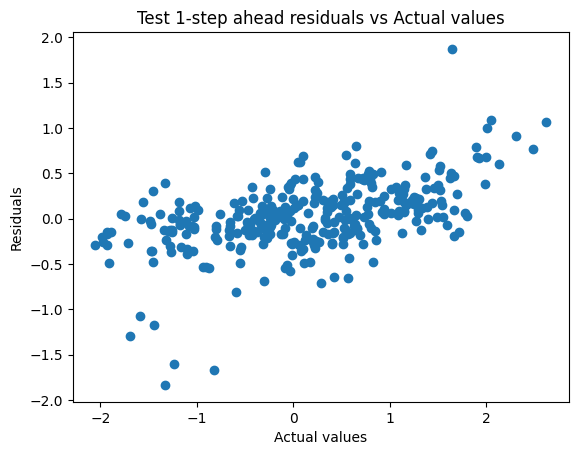

In [46]:
test_resid_1step.plot.hist(bins=10, title="Test 1-step ahead residuals distribution")  
plt.xlabel("Residuals")  
plt.show()  

test_resid_1step.plot(title="Test 1-step ahead residuals time series")  
plt.ylabel("Residuals")  
plt.show() 

plt.scatter(x=y_test["target_t1"].values, y=test_resid_1step.values)  
plt.title("Test 1-step ahead residuals vs Actual values")  
plt.ylabel("Residuals")  
plt.xlabel("Actual values")  
plt.show()  

MAPE test:  [2.67, 3.6999999999999997, 3.7900000000000005, 4.2299999999999995]


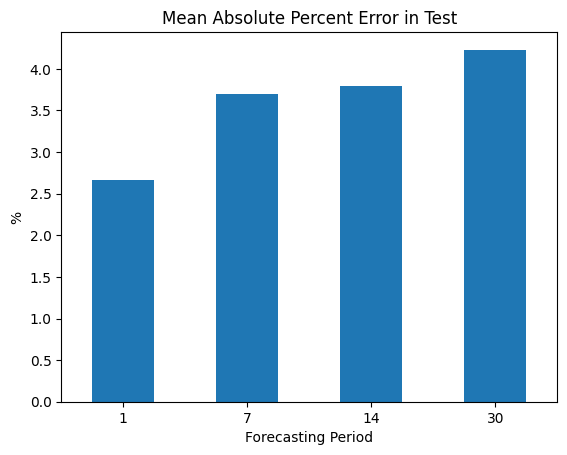

In [48]:
multi_rfr = RandomForestRegressor().set_params(**best_rfr_grid).fit(X_train.loc["2016":"2017"], y_train.loc["2016":"2017"]) 
p_train = multi_rfr.predict(X_train)  
train_resid_1step = y_train- p_train  
  
p_test = multi_rfr.predict(X_test)  
test_resid_1step = y_test- p_test  
periods = [1, 7, 14, 30]  
  
ytest_df = y_test*std+mean  
ptest_df = pd.DataFrame(data=p_test*std+mean, index=test_df.index, columns=["pred_t" + str(i) for i in range(1, 31)])  
test_df = pd.concat([ytest_df, ptest_df], axis=1)  
  
test_MAPE = []  
  
for t in periods:  
    test_df["resid_t" + str(t)] = test_df["target_t" + str(t)].add(-test_df["pred_t" + str(t)])  
    test_df["abs_resid_t" + str(t)] = abs(test_df["resid_t" + str(t)])  
    test_df["ape_t" + str(t)] = test_df["abs_resid_t" + str(t)].div(test_df["target_t" + str(t)])  
    test_MAPE.append(round(test_df["ape_t" + str(t)].mean(), 4)*100)  
  
print("MAPE test: ", test_MAPE)  

mape_df = pd.DataFrame(index=periods, data={"test_MAPE": test_MAPE})  
mape_df.plot(kind="bar", legend=False)  
plt.title("Mean Absolute Percent Error in Test")  
plt.xlabel("Forecasting Period")  
plt.ylabel("%")  
plt.xticks(rotation=0)  
plt.show()  

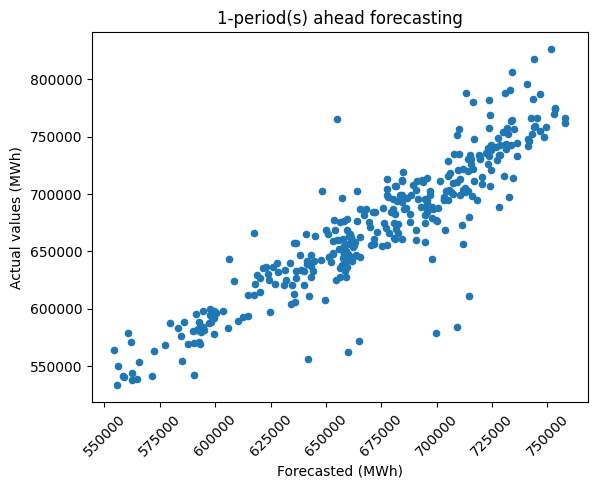

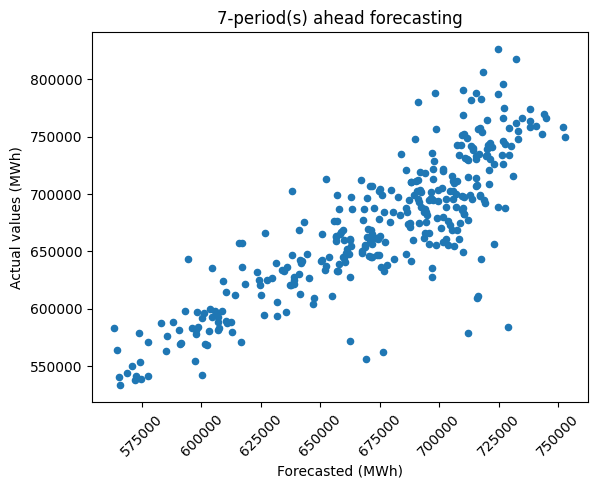

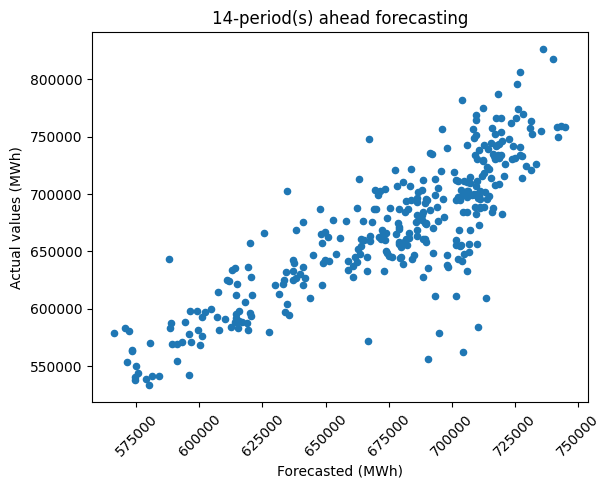

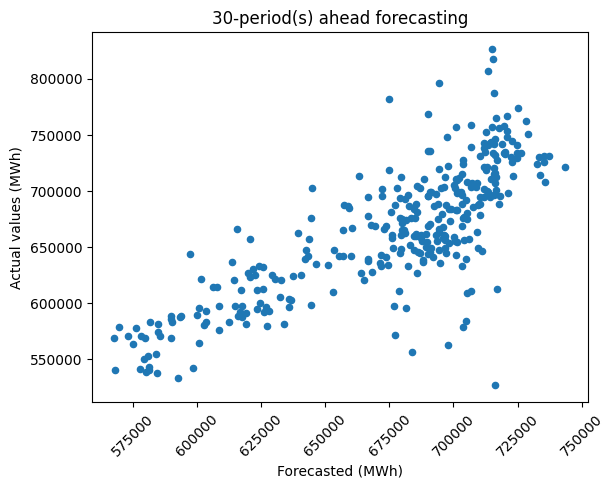

In [50]:
#f, ax = plt.subplots(nrows=3,ncols=2)  
for t in periods:  
    test_df[["target_t" + str(t), "pred_t" + str(t)]].plot(x="pred_t" + str(t), y="target_t" + str(t) ,kind="scatter")  
    plt.title("{}-period(s) ahead forecasting".format(t))  
    plt.xlabel("Forecasted (MWh)")  
    plt.ylabel("Actual values (MWh)")  
    plt.xticks(rotation=45)  
    plt.show()  

In [51]:
test_df.index = test_df.index.date  
forecast_range = pd.date_range(start=np.max(test_df.index.values), periods=tau, freq="D")  
len(forecast_range)  

30

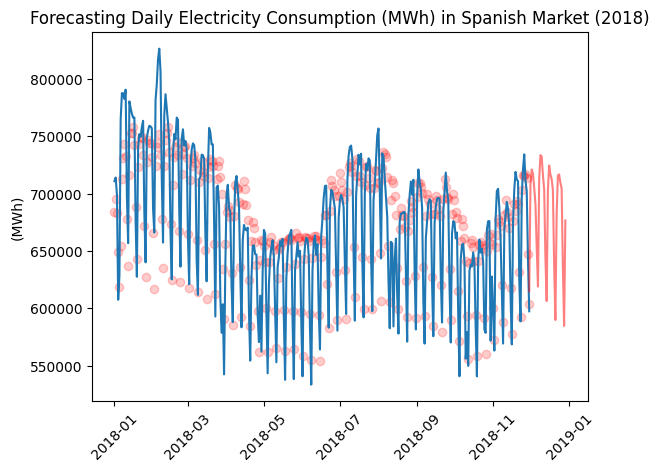

In [52]:
forecast = []  
for t in range(0, tau):  
    #print(-(t+1), (t))  
    forecast = p_test[-(t+1):,(t)]*std+mean  

test_df["target_t1"].plot()  
plt.scatter(x=test_df.index, y=test_df["pred_t1"], c="r", alpha=0.2, label="test preds")  
plt.plot(forecast_range, forecast, c="r", alpha=0.5, label="forecasting")  
plt.ylabel("(MWh)")  
plt.xticks(rotation=45)  
plt.title("Forecasting Daily Electricity Consumption (MWh) in Spanish Market (2018)")  
plt.show()  

In [ ]:
#THE END 